# Model 1A, MLP Experiment 02: Full-History Rotation and W60 Backlog

This append-only experiment gives a regularized Keras multilayer perceptron the exact source-feature hypothesis used by Logistic Regression Experiment 08 and CatBoost Experiment 02: the 20-field raw baseline, all 13 full-history rotation fields with the 24-hour long-turn mask, and the three compact 60-minute backlog fields.

The notebook pairs the established rotation and backlog files in memory after strict identity checks; it does not create a combined feature dataset. Hyperparameters and the classification threshold are selected only from five expanding chronological folds within 2019. The final model is trained on all 2019 rows and evaluated once on 2023. The 2024 final-test year is never loaded. Because BTS records the aircraft that ultimately operated each departure, all rotation results remain a retrospective upper bound until prediction-time tail assignment is verified.


In [1]:
import gc
import os
from itertools import product
from pathlib import Path
from time import perf_counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-capstone")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/xdg-cache-capstone")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, f1_score,
    matthews_corrcoef, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5
MAX_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 6

tf.keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"TensorFlow {tf.__version__}; scikit-learn {sklearn.__version__}")


TensorFlow 2.21.0; scikit-learn 1.9.0


## Pair and validate the Experiment 08 feature paths

Full-history rotation and W60 backlog files are loaded separately. Row identity, target identity, rotation masking, and causal backlog invariants must pass before any model is fitted.


In [2]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in ("rotation_full_history", f"backlog_w{BACKLOG_WINDOW_MINUTES}")
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames = {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation_path = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} backlog rows  <- {backlog_path.name}")


training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 backlog rows  <- JFK_2019_departures_backlog_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 backlog rows  <- JFK_2023_departures_backlog_w60.csv


In [3]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation, backlog = rotation_frames[partition], backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert len(rotation) == len(backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()
    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()
    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1
    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_pending": pending.mean(),
        "same_cutoff_backlog_violations": int(same_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary


,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_pending,same_cutoff_backlog_violations
partition,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0


## Apply the 24-hour mask and define the controlled feature manifest

The six categorical fields are one-hot encoded. The 30 numeric fields receive training-median imputation, explicit missing-value indicators, and standardization. Every preprocessing estimate is learned inside its training fold. This retains all target rows and lets missing rotation values remain informative without giving the network arbitrary sentinel values.


In [4]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
categorical_features = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
numeric_features = [*BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *COMPACT_BACKLOG_FEATURES]
feature_columns = [*categorical_features, *numeric_features]
required_columns = list(dict.fromkeys(["FlightDate", "CRSDepTime", TARGET, *feature_columns]))
assert len(categorical_features) == 6 and len(numeric_features) == 30
assert len(feature_columns) == len(set(feature_columns)) == 36
for partition, frame in model_frames.items():
    assert not set(required_columns).difference(frame.columns), partition
forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(feature_columns)


def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(np.float32)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(model_frames["training"])
validation_model_df = prepare_model_frame(model_frames["validation"])
X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
assert training_dates.max() < validation_dates.min()
missing_summary = pd.DataFrame({
    "training_missing": X_train.isna().sum(),
    "validation_missing": X_validation.isna().sum(),
})
print(pd.Series({"source fields": len(feature_columns), "categorical": len(categorical_features),
                 "numeric": len(numeric_features)}))
missing_summary[missing_summary.sum(axis=1).gt(0)]


source fields    36
categorical       6
numeric          30
dtype: int64


,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
HourlyDewPointTemperature,46,0
HourlyPrecipitation,22,21
HourlyVisibility,0,28
ROTATION_MATCH_FOUND,8281,8409
ROTATION_SCHEDULED_TURN_MINUTES,11877,13310
ROTATION_INBOUND_ARRIVED_BY_CUTOFF,8281,8409
ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,8281,8409
ROTATION_INBOUND_OVERDUE_MINUTES,11877,13310


In [5]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold, "train_rows": len(train_idx), "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
fold_summary


,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1892,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.1780,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.1877,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.2048,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1918,0.1666


## Define fold-local preprocessing and the Keras network

The search compares two modest architectures and two learning rates. Batch size, dropout pattern, and L2 regularization remain fixed to keep the experiment bounded. ReLU hidden layers use batch normalization and dropout; the sigmoid output estimates delay probability. Fold-local early stopping monitors Keras PR AUC, while exact scikit-learn average precision from the held-out probabilities selects the configuration.


In [6]:
def make_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    return ColumnTransformer([
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                      dtype=np.float32), categorical_features),
        ("numeric", numeric_pipeline, numeric_features),
    ], sparse_threshold=0.0, verbose_feature_names_out=True)


def build_network(input_width, parameters, seed):
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(input_width,), name="prepared_features")
    x = inputs
    hidden_units = parameters["hidden_units"]
    for layer_number, units in enumerate(hidden_units):
        x = layers.Dense(
            units, activation="relu",
            kernel_regularizer=regularizers.l2(parameters["l2"]),
            name=f"dense_{layer_number + 1}",
        )(x)
        x = layers.BatchNormalization(name=f"batch_norm_{layer_number + 1}")(x)
        dropout_rate = 0.25 if layer_number == 0 else 0.20
        x = layers.Dropout(dropout_rate, seed=seed + layer_number, name=f"dropout_{layer_number + 1}")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="delay_probability")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=parameters["learning_rate"]),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="pr_auc", curve="PR"),
                 keras.metrics.AUC(name="roc_auc", curve="ROC")],
    )
    return model


parameter_candidates = [
    {"hidden_units": hidden_units, "learning_rate": learning_rate,
     "l2": 1e-4, "batch_size": 512}
    for hidden_units, learning_rate in product([(64, 32), (128, 64, 32)], [1e-3, 3e-4])
]
pd.DataFrame(parameter_candidates)


,hidden_units,learning_rate,l2,batch_size
0,"(64, 32)",0.0010,0.0001,512
1,"(64, 32)",0.0003,0.0001,512
2,"(128, 64, 32)",0.0010,0.0001,512
3,"(128, 64, 32)",0.0003,0.0001,512


## Training-only temporal architecture search

For each chronological fold, preprocessing is fitted once on the earlier block and reused fairly across all four candidates. Early stopping can inspect only that fold's later 2019 block. The median best epoch count for the winning configuration is fixed before generating threshold-selection predictions or fitting all of 2019.


In [7]:
search_start = perf_counter()
search_rows = []
for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    preprocessor = make_preprocessor()
    fold_train_x = np.asarray(preprocessor.fit_transform(X_train.iloc[train_idx]), dtype=np.float32)
    fold_heldout_x = np.asarray(preprocessor.transform(X_train.iloc[heldout_idx]), dtype=np.float32)
    fold_train_y = y_train.iloc[train_idx].to_numpy(dtype=np.float32)
    fold_heldout_y = y_train.iloc[heldout_idx].to_numpy(dtype=np.float32)
    for candidate_number, parameters in enumerate(parameter_candidates, start=1):
        model = build_network(fold_train_x.shape[1], parameters, RANDOM_STATE + fold_number)
        callback = keras.callbacks.EarlyStopping(
            monitor="val_pr_auc", mode="max", patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True, min_delta=1e-4,
        )
        history = model.fit(
            fold_train_x, fold_train_y,
            validation_data=(fold_heldout_x, fold_heldout_y),
            epochs=MAX_EPOCHS, batch_size=parameters["batch_size"],
            callbacks=[callback], verbose=0,
        )
        probabilities = model.predict(fold_heldout_x, batch_size=2048, verbose=0).ravel()
        best_epoch = int(np.argmax(history.history["val_pr_auc"]) + 1)
        search_rows.append({
            "candidate": candidate_number, "fold": fold_number,
            "hidden_units": str(parameters["hidden_units"]),
            "learning_rate": parameters["learning_rate"], "l2": parameters["l2"],
            "batch_size": parameters["batch_size"], "prepared_columns": fold_train_x.shape[1],
            "epochs_run": len(history.history["loss"]), "best_epoch": best_epoch,
            "average_precision": average_precision_score(fold_heldout_y, probabilities),
            "roc_auc": roc_auc_score(fold_heldout_y, probabilities),
            "brier_score": brier_score_loss(fold_heldout_y, probabilities),
        })
        del model, history, probabilities
        keras.backend.clear_session()
        gc.collect()
    print(f"Completed fold {fold_number}/{N_TIME_SPLITS}; prepared columns: {fold_train_x.shape[1]}")
    del preprocessor, fold_train_x, fold_heldout_x, fold_train_y, fold_heldout_y
    gc.collect()

search_seconds = perf_counter() - search_start
fold_search_results = pd.DataFrame(search_rows)
candidate_results = (fold_search_results
    .groupby(["candidate", "hidden_units", "learning_rate", "l2", "batch_size"], as_index=False)
    .agg(mean_average_precision=("average_precision", "mean"),
         std_average_precision=("average_precision", "std"),
         mean_roc_auc=("roc_auc", "mean"), mean_brier_score=("brier_score", "mean"),
         median_best_epoch=("best_epoch", "median"), min_best_epoch=("best_epoch", "min"),
         max_best_epoch=("best_epoch", "max"), median_prepared_columns=("prepared_columns", "median"))
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False))
best_candidate = candidate_results.iloc[0]
selected_parameters = parameter_candidates[int(best_candidate["candidate"]) - 1]
selected_epochs = max(1, int(best_candidate["median_best_epoch"]))
print(f"Temporal search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {best_candidate['mean_average_precision']:.4f}")
print(f"Selected parameters: {selected_parameters}")
print(f"Selected epoch count: {selected_epochs}")
candidate_results


Completed fold 1/5; prepared columns: 184


Completed fold 2/5; prepared columns: 186


Completed fold 3/5; prepared columns: 191


Completed fold 4/5; prepared columns: 193


Completed fold 5/5; prepared columns: 197
Temporal search completed in 158.0 seconds
Best mean temporal-validation AP: 0.6963
Selected parameters: {'hidden_units': (64, 32), 'learning_rate': 0.001, 'l2': 0.0001, 'batch_size': 512}
Selected epoch count: 16


,candidate,hidden_units,learning_rate,l2,batch_size,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_epoch,min_best_epoch,max_best_epoch,median_prepared_columns
0,1,"(64, 32)",0.0010,0.0001,512,0.6963,0.0605,0.8407,0.0925,16.0000,11,19,191.0000
2,3,"(128, 64, 32)",0.0010,0.0001,512,0.6953,0.0616,0.8402,0.0931,12.0000,6,13,191.0000
3,4,"(128, 64, 32)",0.0003,0.0001,512,0.6950,0.0613,0.8400,0.0931,23.0000,15,40,191.0000
1,2,"(64, 32)",0.0003,0.0001,512,0.6945,0.0616,0.8397,0.0931,32.0000,20,45,191.0000


## Select the operating threshold using 2019 only

The winning architecture is refitted for the fixed median epoch count on each earlier fold. These held-out 2019 probabilities select an F1 threshold without using 2023. This deliberate second pass avoids optimistic threshold selection from the early-stopping predictions used to choose the architecture.


In [8]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold, "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
oof_start = perf_counter()
for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    preprocessor = make_preprocessor()
    fold_train_x = np.asarray(preprocessor.fit_transform(X_train.iloc[train_idx]), dtype=np.float32)
    fold_heldout_x = np.asarray(preprocessor.transform(X_train.iloc[heldout_idx]), dtype=np.float32)
    model = build_network(fold_train_x.shape[1], selected_parameters, RANDOM_STATE + 100 + fold_number)
    model.fit(
        fold_train_x, y_train.iloc[train_idx].to_numpy(dtype=np.float32),
        epochs=selected_epochs, batch_size=selected_parameters["batch_size"], verbose=0,
    )
    oof_probabilities[heldout_idx] = model.predict(fold_heldout_x, batch_size=2048, verbose=0).ravel()
    print(f"Completed fixed-epoch threshold fold {fold_number}/{N_TIME_SPLITS}")
    del preprocessor, fold_train_x, fold_heldout_x, model
    keras.backend.clear_session(); gc.collect()

oof_seconds = perf_counter() - oof_start
oof_mask = np.isfinite(oof_probabilities)
oof_y, oof_p = y_train.to_numpy()[oof_mask], oof_probabilities[oof_mask]
threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"], ascending=False
).iloc[0]["threshold"])
print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Fixed-epoch OOF AP: {average_precision_score(oof_y, oof_p):.4f}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(["f1", "balanced_accuracy", "precision"], ascending=False).head(10)


Completed fixed-epoch threshold fold 1/5


Completed fixed-epoch threshold fold 2/5


Completed fixed-epoch threshold fold 3/5


Completed fixed-epoch threshold fold 4/5


Completed fixed-epoch threshold fold 5/5


Threshold-selection rows: 89,693
Fixed-epoch OOF AP: 0.7042
Training-only selected threshold: 0.30


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
25,0.3000,0.8714,0.7502,0.6964,0.5563,0.6185,0.5472,0.8427,0.7042,0.0933
26,0.3100,0.8730,0.7482,0.7083,0.5486,0.6183,0.5500,0.8427,0.7042,0.0933
27,0.3200,0.8745,0.7462,0.7201,0.5409,0.6178,0.5525,0.8427,0.7042,0.0933
24,0.2900,0.8692,0.7516,0.6831,0.5635,0.6176,0.5432,0.8427,0.7042,0.0933
23,0.2800,0.8667,0.7531,0.6692,0.5714,0.6165,0.5389,0.8427,0.7042,0.0933
28,0.3300,0.8755,0.7440,0.7296,0.5335,0.6163,0.5537,0.8427,0.7042,0.0933
22,0.2700,0.8644,0.7551,0.6563,0.5804,0.6160,0.5355,0.8427,0.7042,0.0933
21,0.2600,0.8617,0.7574,0.6425,0.5907,0.6155,0.5321,0.8427,0.7042,0.0933
20,0.2500,0.8590,0.7600,0.6297,0.6016,0.6153,0.5293,0.8427,0.7042,0.0933
29,0.3400,0.8765,0.7417,0.7397,0.5262,0.6149,0.5550,0.8427,0.7042,0.0933


## Refit on all 2019 rows and evaluate 2023

The final preprocessing transform is fitted on all 2019 rows, followed by the selected network trained for the fixed epoch count. No 2023 outcome influences preprocessing, architecture, regularization, learning rate, epoch count, or threshold. Logistic Regression 08 and CatBoost 02 are documented benchmarks rather than refitted models.


In [9]:
final_fit_start = perf_counter()
final_preprocessor = make_preprocessor()
final_train_x = np.asarray(final_preprocessor.fit_transform(X_train), dtype=np.float32)
final_validation_x = np.asarray(final_preprocessor.transform(X_validation), dtype=np.float32)
best_mlp_model = build_network(final_train_x.shape[1], selected_parameters, RANDOM_STATE + 999)
final_history = best_mlp_model.fit(
    final_train_x, y_train.to_numpy(dtype=np.float32),
    epochs=selected_epochs, batch_size=selected_parameters["batch_size"], verbose=0,
)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_mlp_model.predict(final_validation_x, batch_size=2048, verbose=0).ravel()
evaluation_results = pd.DataFrame([
    {"model": "Logistic Regression 08 (documented)", "threshold": 0.50,
     "accuracy": 0.8430, "balanced_accuracy": 0.6953, "precision": 0.8395,
     "recall": 0.4151, "f1": 0.5555, "mcc": 0.5164,
     "roc_auc": 0.8267, "average_precision": 0.7053, "brier_score": 0.1192},
    {"model": "CatBoost 02 (documented)", "threshold": 0.50,
     "accuracy": 0.8548, "balanced_accuracy": 0.7139, "precision": 0.8796,
     "recall": 0.4467, "f1": 0.5925, "mcc": 0.5592,
     "roc_auc": 0.8511, "average_precision": 0.7473, "brier_score": 0.1100},
    {"model": "MLP 02 (default)", **evaluate_probabilities(y_validation, validation_probabilities, 0.50)},
    {"model": "MLP 02 (training-selected)",
     **evaluate_probabilities(y_validation, validation_probabilities, selected_threshold)},
]).set_index("model")
print(f"Prepared input columns: {final_train_x.shape[1]:,}")
print(f"Trainable parameters: {best_mlp_model.count_params():,}")
print(f"Final all-2019 fit: {final_fit_seconds:,.1f} seconds; epochs: {selected_epochs}")
evaluation_results


Prepared input columns: 202
Trainable parameters: 15,489
Final all-2019 fit: 6.8 seconds; epochs: 16


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 08 (documented),0.5000,0.8430,0.6953,0.8395,0.4151,0.5555,0.5164,0.8267,0.7053,0.1192
CatBoost 02 (documented),0.5000,0.8548,0.7139,0.8796,0.4467,0.5925,0.5592,0.8511,0.7473,0.1100
MLP 02 (default),0.5000,0.8545,0.7132,0.8794,0.4454,0.5913,0.5581,0.8446,0.7405,0.1112
MLP 02 (training-selected),0.3000,0.8468,0.7530,0.7204,0.5751,0.6396,0.5495,0.8446,0.7405,0.1112


In [10]:
validation_frame = model_frames["validation"].sort_values(
    ["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
status = validation_frame["ROTATION_STATUS"].astype("string")
populations = {
    "all rows": np.ones(len(validation_frame), dtype=bool),
    "excluding NOT_ARRIVED": status.ne("NOT_ARRIVED").to_numpy(),
    "ARRIVED": status.eq("ARRIVED").to_numpy(),
    "rotation unavailable/excluded": status.isin([
        "NO_PRIOR_EVENT", "PREVIOUS_EVENT_DEPARTURE", "MISSING_TAIL", "LONG_TURN_EXCLUDED"
    ]).to_numpy(),
}
diagnostic_rows = []
for population, mask in populations.items():
    subgroup_y, subgroup_p = y_validation.to_numpy()[mask], validation_probabilities[mask]
    diagnostic_rows.append({
        "population": population, "rows": int(mask.sum()), "prevalence": subgroup_y.mean(),
        "average_precision": average_precision_score(subgroup_y, subgroup_p),
        "roc_auc": roc_auc_score(subgroup_y, subgroup_p),
        "brier_score": brier_score_loss(subgroup_y, subgroup_p),
    })
diagnostic_results = pd.DataFrame(diagnostic_rows).set_index("population")
diagnostic_results


,rows,prevalence,average_precision,roc_auc,brier_score
population,,,,,
all rows,109983,0.2364,0.7405,0.8446,0.1112
excluding NOT_ARRIVED,106418,0.2109,0.6649,0.8201,0.1148
ARRIVED,93108,0.1858,0.6495,0.8132,0.1028
rotation unavailable/excluded,13310,0.3866,0.6730,0.7532,0.1989


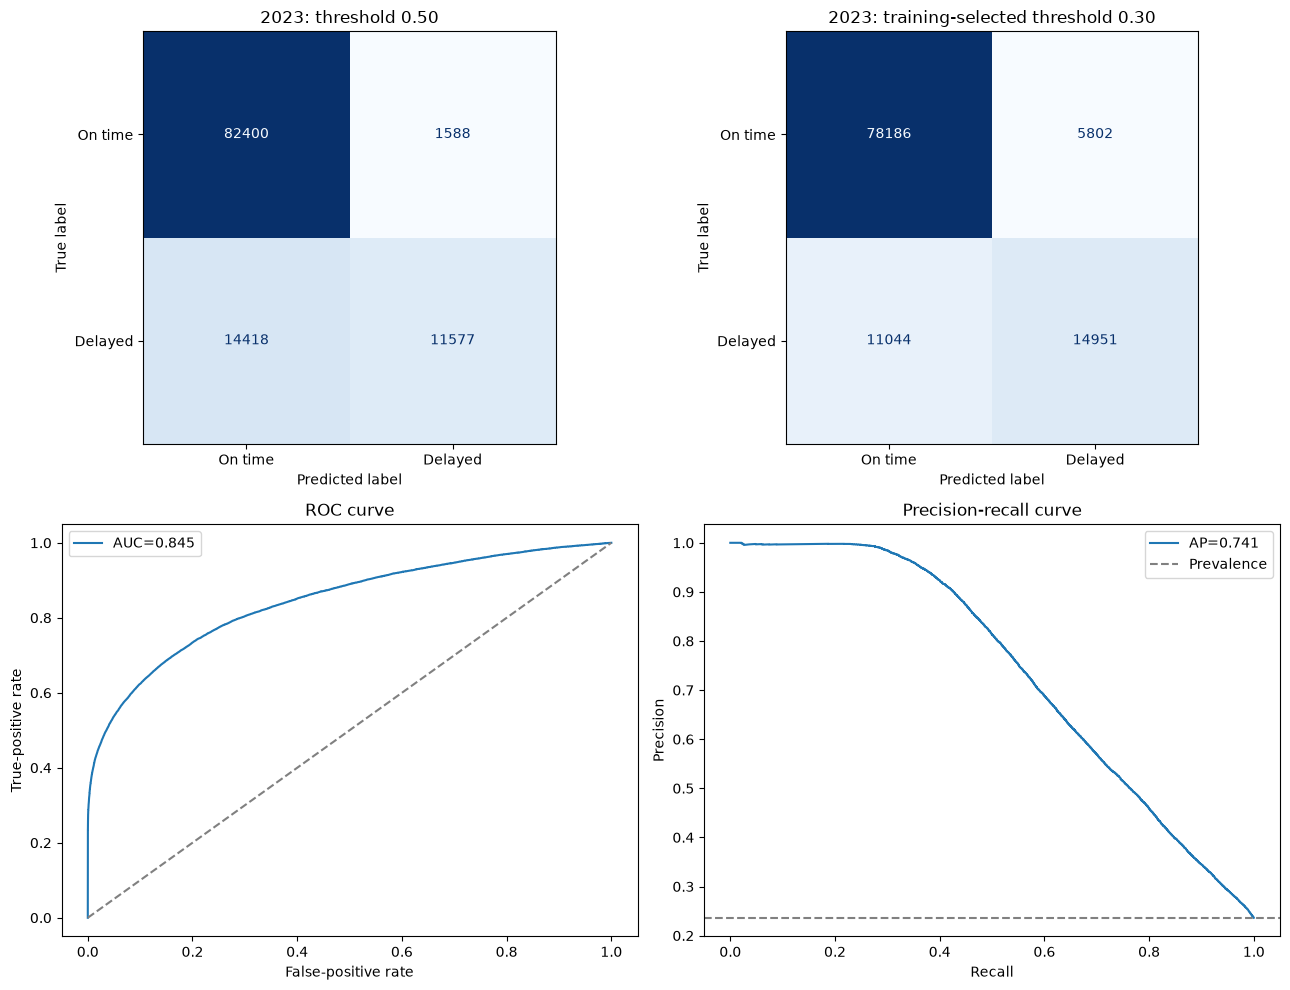

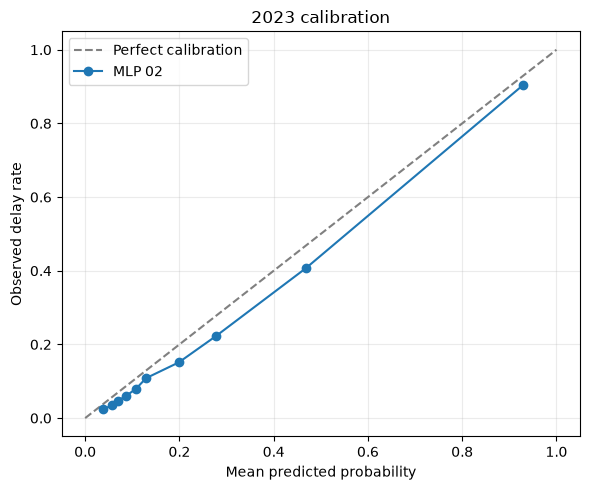

In [11]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(y_validation, default_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(y_validation, selected_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 1])
axes[0, 1].set_title(f"2023: training-selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(false_positive_rate, true_positive_rate,
                label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curve")
axes[1, 0].legend()
axes[1, 1].plot(curve_recall, curve_precision,
                label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}")
axes[1, 1].axhline(y_validation.mean(), linestyle="--", color="gray", label="Prevalence")
axes[1, 1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
axes[1, 1].legend(); fig.tight_layout(); plt.show()

predicted, observed = calibration_curve(y_validation, validation_probabilities, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="MLP 02")
ax.set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="2023 calibration")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()


## Inspect grouped permutation importance and publishable values

Permutation importance is calculated on a fixed 20,000-row 2023 diagnostic sample. Each source field is shuffled as one unit before applying the fitted preprocessing transform, so categorical fields and their one-hot columns remain grouped. The score is the reduction in average precision. These values describe the fitted model and do not establish causation.


In [12]:
importance_sample = X_validation.sample(n=min(20_000, len(X_validation)), random_state=RANDOM_STATE)
importance_y = y_validation.loc[importance_sample.index].to_numpy()
importance_base_x = np.asarray(final_preprocessor.transform(importance_sample), dtype=np.float32)
importance_base_p = best_mlp_model.predict(importance_base_x, batch_size=2048, verbose=0).ravel()
importance_base_ap = average_precision_score(importance_y, importance_base_p)
rng = np.random.default_rng(RANDOM_STATE)
permutation_rows = []
for column in feature_columns:
    permuted = importance_sample.copy()
    permuted[column] = rng.permutation(permuted[column].to_numpy())
    permuted_x = np.asarray(final_preprocessor.transform(permuted), dtype=np.float32)
    permuted_p = best_mlp_model.predict(permuted_x, batch_size=2048, verbose=0).ravel()
    permutation_rows.append({
        "feature": column,
        "permuted_average_precision": average_precision_score(importance_y, permuted_p),
        "average_precision_decrease": importance_base_ap - average_precision_score(importance_y, permuted_p),
    })
permutation_importance = pd.DataFrame(permutation_rows).sort_values(
    "average_precision_decrease", ascending=False).reset_index(drop=True)
display(permutation_importance.head(25))
display(permutation_importance[permutation_importance["feature"].str.contains("ROTATION_|BACKLOG_", regex=True)])


,feature,permuted_average_precision,average_precision_decrease
0,ROTATION_LOG_ACTUAL_TURN_MINUTES,0.5176,0.2168
1,ROTATION_LOG_INBOUND_OVERDUE_MINUTES,0.6753,0.0591
2,ROTATION_LOG_SCHEDULED_TURN_MINUTES,0.7086,0.0257
3,Reporting_Airline,0.7102,0.0242
4,ROTATION_INBOUND_ARR_DELAY,0.7106,0.0237
5,ROTATION_STATUS,0.7191,0.0152
6,ROTATION_INBOUND_DELAYED_15,0.7205,0.0139
7,ROTATION_INBOUND_ARRIVED_BY_CUTOFF,0.7211,0.0133
8,CRSDepTime,0.7219,0.0125
9,BACKLOG_W60_PENDING_COUNT,0.7242,0.0101


,feature,permuted_average_precision,average_precision_decrease
0,ROTATION_LOG_ACTUAL_TURN_MINUTES,0.5176,0.2168
1,ROTATION_LOG_INBOUND_OVERDUE_MINUTES,0.6753,0.0591
2,ROTATION_LOG_SCHEDULED_TURN_MINUTES,0.7086,0.0257
4,ROTATION_INBOUND_ARR_DELAY,0.7106,0.0237
5,ROTATION_STATUS,0.7191,0.0152
6,ROTATION_INBOUND_DELAYED_15,0.7205,0.0139
7,ROTATION_INBOUND_ARRIVED_BY_CUTOFF,0.7211,0.0133
9,BACKLOG_W60_PENDING_COUNT,0.7242,0.0101
10,ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,0.7243,0.0100
11,ROTATION_INBOUND_OVERDUE_MINUTES,0.7251,0.0092


In [13]:
default = evaluation_results.loc["MLP 02 (default)"]
selected = evaluation_results.loc["MLP 02 (training-selected)"]
publishable_summary = pd.Series({
    "TensorFlow version": tf.__version__, "source fields": len(feature_columns),
    "prepared input columns": final_train_x.shape[1],
    "hidden units": str(selected_parameters["hidden_units"]),
    "learning rate": selected_parameters["learning_rate"], "L2": selected_parameters["l2"],
    "batch size": selected_parameters["batch_size"], "selected epochs": selected_epochs,
    "trainable parameters": best_mlp_model.count_params(),
    "training CV AP": best_candidate["mean_average_precision"],
    "validation prevalence": y_validation.mean(), "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"], "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold, "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"], "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"], "selected-threshold MCC": selected["mcc"],
    "validation AP excluding NOT_ARRIVED": diagnostic_results.loc["excluding NOT_ARRIVED", "average_precision"],
    "search seconds": search_seconds, "OOF seconds": oof_seconds, "final fit seconds": final_fit_seconds,
}, name="MLP 1A Experiment 02 Appendix D values")
publishable_summary.to_frame()


,MLP 1A Experiment 02 Appendix D values
TensorFlow version,2.21.0
source fields,36
prepared input columns,202
hidden units,"(64, 32)"
learning rate,0.0010
L2,0.0001
batch size,512
selected epochs,16
trainable parameters,15489
training CV AP,0.6963


## Interpretation checklist

1. Does the regularized MLP improve 2019 temporal AP and 2023 AP, ROC AUC, or Brier score over Logistic Regression 08?
2. Does it approach or exceed CatBoost 02 on the same source fields and validation rows?
3. Does any gain persist after excluding `NOT_ARRIVED` and among already-arrived rotations?
4. Do the permutation diagnostics show use of both rotation and W60 backlog information?
5. Is the improvement large and stable enough to justify a more complex categorical-embedding experiment?
6. Preserve the final-tail caveat: this remains a retrospective upper bound until timestamped assignment data are available.
